<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/PVT/pvt_workflow_from_lab_to_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Complete PVT workflow: from laboratory data to simulator-ready models

This workbook demonstrates the end-to-end NeqSim workflow described in the
[PVT workflow guide](https://equinor.github.io/neqsim/pvtsimulation/pvt_workflow.html).
It turns a transparent synthetic bottom-hole sample into a characterized compositional
fluid, checks laboratory-style experiments, performs a bounded regression, optimizes a
separator train, generates an auditable report, and exports validated black-oil and E300
deliverables.

The notebook is deliberately output-complete: tables, plots, regression diagnostics,
export previews, hashes, and acceptance checks are stored with the notebook.

## Learning outcomes and acceptance criteria

After completing the workbook, you should be able to:

1. quality-control a compositional assay and characterize a plus fraction;
2. simulate saturation pressure, CCE, DLE, viscosity, and separator tests;
3. assemble a multi-experiment `PVTRegression` data package;
4. select a bounded and identifiable regression parameter;
5. compare laboratory and calculated values with independent residual metrics;
6. optimize first-stage separator pressure and temperature;
7. produce a Markdown report, CSV tables, a black-oil include, and an E300 file; and
8. fail closed if balances, units, trends, regression quality, or exports are invalid.

Completion requires all executable checks near the end of the notebook to pass.

## Workflow and evidence chain

| Stage | Input | NeqSim calculation | Evidence retained |
|---|---|---|---|
| Sample QC | laboratory composition and conditions | normalization and assay audit | input tables and closure |
| Fluid model | named components, TBP cuts, C20+ | SRK, Pedersen characterization, classic mixing | component slate |
| PVT experiments | pressure and temperature schedules | bubble point, CCE, DLE, viscosity | tables, plots, residuals |
| Regression | lab viscosity and parameter bounds | Levenberg-Marquardt through `PVTRegression` | fit, objective, uncertainty |
| Surface test | staged pressure and temperature | equilibrium separator train and grid search | recovery surface and optimum |
| Handoff | tuned fluid and PVT tables | report, CSV, black-oil and E300 export | previews, round trip, hashes |

The evidence level is a synthetic regression benchmark plus thermodynamic consistency,
trend, round-trip, and schema checks. It is not a match to proprietary laboratory data.

## Basis, units, and limitations of the teaching dataset

- All pressures are absolute and reported in bara.
- NeqSim receives thermodynamic temperatures in kelvin unless a method explicitly accepts `"C"`.
- Standard volumes use 15°C and 1.01325 bara.
- Composition is on a 100 mol basis before normalization.
- The equation of state is SRK with the classic mixing rule and volume correction.
- The assay and laboratory deviations are synthetic and public-domain teaching data.
- `MultiStageSeparatorTest.setReservoirConditions` receives temperature in °C in NeqSim 3.16.0.

Replace the dataset, standard-condition definition, weights, uncertainty model, and acceptance
limits before using the workflow for an asset decision.

In [1]:
import importlib.util
import subprocess
import sys


required_packages = {
    "neqsim": "neqsim==3.16.0",
    "matplotlib": "matplotlib>=3.8",
    "numpy": "numpy>=1.25",
    "pandas": "pandas>=2.0",
}
missing_requirements = [
    requirement
    for module_name, requirement in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_requirements:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_requirements]
    )

print("Runtime dependencies are available.")

Runtime dependencies are available.


In [2]:
import hashlib
import json
import platform
from importlib.metadata import version
from pathlib import Path

import jpype
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from jpype import JClass
from neqsim import jneqsim
from neqsim.thermo import TPflash


plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 6)

VERSION_INFO = {
    "neqsim": version("neqsim"),
    "python": platform.python_version(),
    "java": str(jpype.java.lang.System.getProperty("java.version")),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
}
display(pd.DataFrame(VERSION_INFO.items(), columns=["software", "version"]))

,software,version
0,neqsim,3.16.0
1,python,3.12.13
2,java,17.0.19
3,numpy,2.5.1
4,pandas,3.0.3
5,matplotlib,3.11.1


## 1. Sample information and compositional assay

A laboratory report normally starts with sample identity, sampling conditions, reservoir
conditions, and a compositional analysis. The values below are synthetic, but the schema is
suitable for replacing them with a validated bottom-hole or recombined surface sample.

In [3]:
RESERVOIR_TEMPERATURE_C = 97.5
RESERVOIR_TEMPERATURE_K = RESERVOIR_TEMPERATURE_C + 273.15
RESERVOIR_PRESSURE_BARA = 300.0
STANDARD_TEMPERATURE_C = 15.0
STANDARD_PRESSURE_BARA = 1.01325
WATER_DENSITY_60F_KG_M3 = 999.016

sample_information = pd.DataFrame(
    {
        "field": [
            "sample identifier",
            "sample type",
            "sampling depth",
            "reservoir pressure",
            "reservoir temperature",
            "standard temperature",
            "standard pressure",
        ],
        "value": [
            "Teaching-BHS-01",
            "synthetic bottom-hole sample",
            2850.0,
            RESERVOIR_PRESSURE_BARA,
            RESERVOIR_TEMPERATURE_C,
            STANDARD_TEMPERATURE_C,
            STANDARD_PRESSURE_BARA,
        ],
        "unit": ["-", "-", "m TVD", "bara", "°C", "°C", "bara"],
    }
)
display(sample_information)

,field,value,unit
0,sample identifier,Teaching-BHS-01,-
1,sample type,synthetic bottom-hole sample,-
2,sampling depth,2850.0,m TVD
3,reservoir pressure,300.0,bara
4,reservoir temperature,97.5,°C
5,standard temperature,15.0,°C
6,standard pressure,1.01325,bara


In [4]:
LIGHT_COMPONENTS = [
    ("nitrogen", 0.39),
    ("CO2", 0.30),
    ("methane", 40.20),
    ("ethane", 7.61),
    ("propane", 7.95),
    ("i-butane", 1.19),
    ("n-butane", 4.08),
    ("i-pentane", 1.39),
    ("n-pentane", 2.15),
    ("n-hexane", 2.79),
]

TBP_CUTS = [
    ("C7", 4.28, 0.095, 0.729),
    ("C8", 4.31, 0.106, 0.749),
    ("C9", 3.08, 0.121, 0.770),
    ("C10", 2.47, 0.135, 0.786),
    ("C11", 1.91, 0.148, 0.792),
    ("C12", 1.69, 0.161, 0.804),
    ("C13", 1.59, 0.175, 0.819),
    ("C14", 1.22, 0.196, 0.833),
    ("C15", 1.25, 0.206, 0.836),
    ("C16", 1.00, 0.225, 0.843),
    ("C17", 0.99, 0.236, 0.840),
    ("C18", 0.92, 0.245, 0.846),
    ("C19", 0.60, 0.265, 0.857),
]

PLUS_FRACTION = ("C20", 6.64, 0.453, 0.918)

composition_rows = [
    {
        "component_or_cut": name,
        "type": "named component",
        "amount_mol_percent": amount,
        "molar_mass_kg_mol": np.nan,
        "relative_density": np.nan,
    }
    for name, amount in LIGHT_COMPONENTS
]
composition_rows.extend(
    {
        "component_or_cut": name,
        "type": "TBP cut",
        "amount_mol_percent": amount,
        "molar_mass_kg_mol": molar_mass,
        "relative_density": relative_density,
    }
    for name, amount, molar_mass, relative_density in TBP_CUTS
)
composition_rows.append(
    {
        "component_or_cut": PLUS_FRACTION[0] + "+",
        "type": "plus fraction",
        "amount_mol_percent": PLUS_FRACTION[1],
        "molar_mass_kg_mol": PLUS_FRACTION[2],
        "relative_density": PLUS_FRACTION[3],
    }
)
input_composition = pd.DataFrame(composition_rows)
assay_total_mol_percent = input_composition["amount_mol_percent"].sum()

display(input_composition)
print(f"Assay total: {assay_total_mol_percent:.12f} mol%")

Assay total: 100.000000000000 mol%


,component_or_cut,type,amount_mol_percent,molar_mass_kg_mol,relative_density
0,nitrogen,named component,0.39,NaN,NaN
1,CO2,named component,0.30,NaN,NaN
2,methane,named component,40.20,NaN,NaN
3,ethane,named component,7.61,NaN,NaN
4,propane,named component,7.95,NaN,NaN
5,i-butane,named component,1.19,NaN,NaN
6,n-butane,named component,4.08,NaN,NaN
7,i-pentane,named component,1.39,NaN,NaN
8,n-pentane,named component,2.15,NaN,NaN
9,n-hexane,named component,2.79,NaN,NaN


The reported amounts are normalized internally. The required closure is

$$
\sum_{i=1}^{N} z_i = 1,
$$

where $z_i$ is the overall mole fraction of component or characterized pseudo-component $i$.
A laboratory total outside the project's tolerance should be investigated before normalization;
silent normalization can conceal transcription errors or missing fractions.

## 2. Build and characterize the initial fluid

The initial model uses SRK, Pedersen TBP and plus-fraction characterization, twelve total
pseudo-components for the C7+ material, the classic mixing rule, and volume correction. The
number of pseudo-components is a modelling choice and should be checked for convergence.

In [5]:
def build_reservoir_oil():
    system = jneqsim.thermo.system.SystemSrkEos(
        RESERVOIR_TEMPERATURE_K,
        RESERVOIR_PRESSURE_BARA,
    )

    for component_name, amount_mol in LIGHT_COMPONENTS:
        system.addComponent(component_name, amount_mol)

    for cut_name, amount_mol, molar_mass, relative_density in TBP_CUTS:
        system.addTBPfraction(
            cut_name,
            amount_mol,
            molar_mass,
            relative_density,
        )

    plus_name, plus_amount, plus_molar_mass, plus_density = PLUS_FRACTION
    system.addPlusFraction(
        plus_name,
        plus_amount,
        plus_molar_mass,
        plus_density,
    )

    characterization = system.getCharacterization()
    characterization.getLumpingModel().setNumberOfPseudoComponents(12)
    characterization.characterisePlusFraction()

    system.setMixingRule("classic")
    system.useVolumeCorrection(True)
    system.init(0)
    system.init(1)
    return system


reservoir_oil = build_reservoir_oil()
print("Characterized fluid created.")

Characterized fluid created.


In [6]:
characterized_rows = []

for component_index in range(reservoir_oil.getNumberOfComponents()):
    component = reservoir_oil.getComponent(component_index)
    characterized_rows.append(
        {
            "component": str(component.getComponentName()),
            "mole_fraction": float(component.getz()),
            "molar_mass_g_mol": 1000.0 * float(component.getMolarMass()),
        }
    )

characterized_composition = pd.DataFrame(characterized_rows)
characterized_sum = characterized_composition["mole_fraction"].sum()
characterized_molar_mass = reservoir_oil.getMolarMass("kg/mol")

characterization_audit = pd.DataFrame(
    {
        "quantity": [
            "input assay total",
            "characterized components",
            "characterized composition sum",
            "fluid-average molar mass",
        ],
        "value": [
            assay_total_mol_percent,
            reservoir_oil.getNumberOfComponents(),
            characterized_sum,
            characterized_molar_mass,
        ],
        "unit": ["mol%", "count", "mol/mol", "kg/mol"],
    }
)

display(characterization_audit)
display(characterized_composition)

,quantity,value,unit
0,input assay total,100.00000,mol%
1,characterized components,22.00000,count
2,characterized composition sum,1.00000,mol/mol
3,fluid-average molar mass,0.08797,kg/mol


,component,mole_fraction,molar_mass_g_mol
0,nitrogen,0.003900,28.013500
1,CO2,0.003000,44.010000
2,methane,0.402000,16.043000
3,ethane,0.076100,30.070000
4,propane,0.079500,44.097000
5,i-butane,0.011900,58.123000
6,n-butane,0.040800,58.123000
7,i-pentane,0.013900,72.151000
8,n-pentane,0.021500,72.150000
9,n-hexane,0.027900,86.177000


## 3. Reservoir reference state and saturation pressure

The reference state is flashed independently before laboratory experiments are simulated.
Saturation pressure is calculated at the reservoir temperature and later cross-checked against
the CCE and DLE responses.

In [7]:
reference_state = reservoir_oil.clone()
reference_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
reference_state.setPressure(350.0, "bara")
TPflash(reference_state)
reference_state.initPhysicalProperties()

reference_oil_phase = reference_state.getPhase("oil")
reference_density_kg_m3 = reference_oil_phase.getDensity("kg/m3")
reference_viscosity_cp = reference_oil_phase.getViscosity("cP")

SaturationPressure = jneqsim.pvtsimulation.simulation.SaturationPressure
saturation_calculation = SaturationPressure(reservoir_oil.clone())
saturation_calculation.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
saturation_calculation.run()
bubble_pressure_bara = saturation_calculation.getSaturationPressure()

reference_summary = pd.DataFrame(
    {
        "property": [
            "phase count at reference state",
            "oil density at 350 bara",
            "oil viscosity at 350 bara",
            "bubble pressure at reservoir temperature",
        ],
        "value": [
            reference_state.getNumberOfPhases(),
            reference_density_kg_m3,
            reference_viscosity_cp,
            bubble_pressure_bara,
        ],
        "unit": ["count", "kg/m3", "cP", "bara"],
    }
)
display(reference_summary)

,property,value,unit
0,phase count at reference state,1.000000,count
1,oil density at 350 bara,677.376873,kg/m3
2,oil viscosity at 350 bara,0.265224,cP
3,bubble pressure at reservoir temperature,193.240934,bara


## 4. Constant-composition expansion

CCE changes pressure at fixed temperature without removing material. Relative volume is

$$
V_r(P) = \frac{V(P,T)}{V(P_b,T)},
$$

where $P_b$ is the bubble pressure. A small deterministic laboratory deviation is added to the
synthetic calculated values so that the comparison and reporting paths exercise non-zero
residuals. It does not represent experimental uncertainty for a real laboratory.

In [8]:
ConstantMassExpansion = jneqsim.pvtsimulation.simulation.ConstantMassExpansion
cce_pressures_bara = np.array(
    [300.0, 250.0, 220.0, 200.0, bubble_pressure_bara, 180.0, 150.0, 100.0]
)
cce_experiment = ConstantMassExpansion(reservoir_oil.clone())
cce_experiment.setPressures(cce_pressures_bara.tolist())
cce_experiment.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
cce_experiment.runCalc()

cce_calculated_relative_volume = np.asarray(
    cce_experiment.getRelativeVolume(),
    dtype=float,
)
cce_y_factor = np.asarray(cce_experiment.getYfactor(), dtype=float)
cce_lab_multiplier = np.array(
    [1.001, 0.999, 1.002, 1.000, 1.001, 0.998, 1.002, 0.999]
)
cce_lab_relative_volume = cce_calculated_relative_volume * cce_lab_multiplier
cce_relative_error_percent = 100.0 * (
    cce_calculated_relative_volume - cce_lab_relative_volume
) / cce_lab_relative_volume

cce_results = pd.DataFrame(
    {
        "pressure_bara": cce_pressures_bara,
        "lab_relative_volume": cce_lab_relative_volume,
        "calculated_relative_volume": cce_calculated_relative_volume,
        "relative_error_percent": cce_relative_error_percent,
        "Y_factor": cce_y_factor,
    }
)
cce_aard_percent = np.mean(np.abs(cce_relative_error_percent))
display(cce_results)
print(f"CCE AARD: {cce_aard_percent:.4f}%")

CCE AARD: 0.1250%


,pressure_bara,lab_relative_volume,calculated_relative_volume,relative_error_percent,Y_factor
0,300.000000,0.970098,0.969128,-0.099900,NaN
1,250.000000,0.981224,0.982206,0.100100,NaN
2,220.000000,0.993131,0.991149,-0.199601,NaN
3,200.000000,0.997666,0.997666,0.000000,NaN
4,193.240934,1.000981,0.999981,-0.099900,NaN
5,180.000000,1.025964,1.028020,0.200401,2.614704
6,150.000000,1.120366,1.118130,-0.199601,2.437292
7,100.000000,1.433998,1.435433,0.100100,2.140113


## 5. Differential liberation

DLE reduces pressure at reservoir temperature and removes equilibrium gas after each stage.
The primary oil quantities are

$$
B_o = \frac{V_o(P,T)}{V_{o,\mathrm{sc}}},
$$

and

$$
R_s = \frac{V_{g,\mathrm{sc}}^{\mathrm{dissolved}}}
{V_{o,\mathrm{sc}}}.
$$

DLE is a laboratory depletion path, not a surface separator train. The separator experiment is
handled separately below.

In [9]:
DifferentialLiberation = jneqsim.pvtsimulation.simulation.DifferentialLiberation
dle_pressures_bara = np.array(
    [300.0, 250.0, 220.0, 200.0, 180.0, 150.0, 100.0, 50.0, 1.01325]
)
dle_experiment = DifferentialLiberation(reservoir_oil.clone())
dle_experiment.setPressures(dle_pressures_bara.tolist())
dle_experiment.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
dle_experiment.runCalc()

dle_bo = np.asarray(dle_experiment.getBo(), dtype=float)
dle_rs = np.asarray(dle_experiment.getRs(), dtype=float)
dle_density_kg_m3 = np.asarray(dle_experiment.getOilDensity(), dtype=float)
dle_bg = np.asarray(dle_experiment.getBg(), dtype=float)

dle_bo_lab = dle_bo * np.array(
    [0.999, 1.001, 0.998, 1.001, 0.999, 1.002, 0.998, 1.001, 1.000]
)
dle_rs_lab = dle_rs * np.array(
    [1.002, 0.999, 1.001, 0.998, 1.002, 0.999, 1.001, 0.998, 1.000]
)
dle_density_lab = dle_density_kg_m3 * np.array(
    [1.001, 0.999, 1.001, 1.000, 0.999, 1.001, 0.999, 1.001, 1.000]
)

dle_results = pd.DataFrame(
    {
        "pressure_bara": dle_pressures_bara,
        "lab_Bo_m3_Sm3": dle_bo_lab,
        "calculated_Bo_m3_Sm3": dle_bo,
        "lab_Rs_Sm3_Sm3": dle_rs_lab,
        "calculated_Rs_Sm3_Sm3": dle_rs,
        "lab_oil_density_kg_m3": dle_density_lab,
        "calculated_oil_density_kg_m3": dle_density_kg_m3,
        "Bg_m3_Sm3": dle_bg,
    }
)
display(dle_results)
print(
    "DLE saturation pressure: "
    f"{dle_experiment.getSaturationPressure():.6f} bara"
)

DLE saturation pressure: 193.187586 bara


,pressure_bara,lab_Bo_m3_Sm3,calculated_Bo_m3_Sm3,lab_Rs_Sm3_Sm3,calculated_Rs_Sm3_Sm3,lab_oil_density_kg_m3,calculated_oil_density_kg_m3,Bg_m3_Sm3
0,300.00000,1.762530,1.764295,225.122055,224.672710,669.699465,669.030434,0.000000
1,250.00000,1.791319,1.789529,224.448037,224.672710,658.936617,659.596213,0.000000
2,220.00000,1.803172,1.806786,224.897383,224.672710,653.949695,653.296398,0.000000
3,200.00000,1.821181,1.819362,224.223365,224.672710,648.780648,648.780648,0.000000
4,180.00000,1.777520,1.779300,209.436292,209.018255,654.175177,654.830007,0.006301
5,150.00000,1.690863,1.687488,176.349632,176.526158,672.823318,672.151167,0.007562
6,100.00000,1.549622,1.552728,129.100217,128.971246,700.925173,701.626800,0.011533
7,50.00000,1.428955,1.427528,86.105012,86.277567,733.881302,733.148153,0.023873
8,1.01325,1.050859,1.050859,0.000000,0.000000,810.424578,810.424578,1.271652


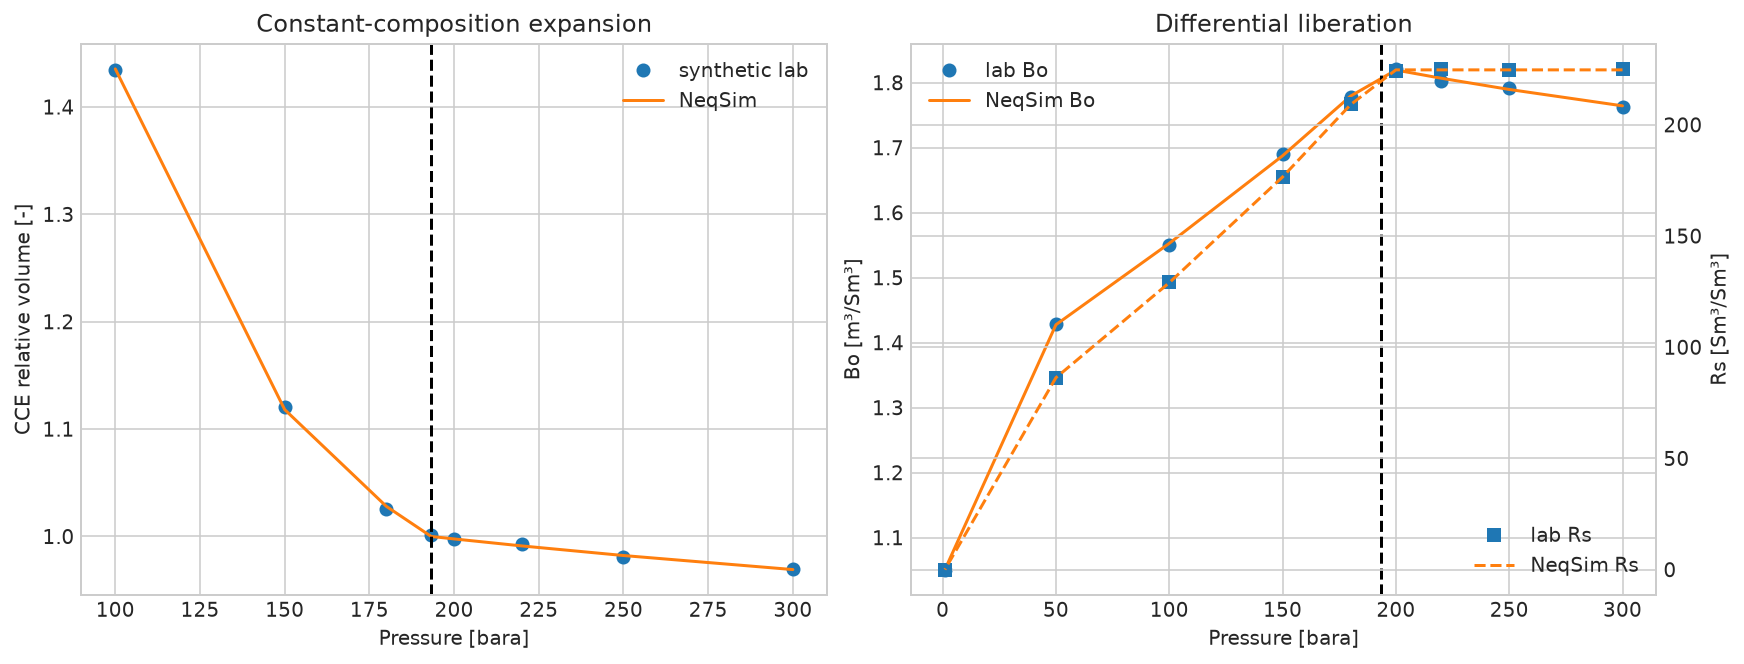

In [10]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(
    cce_results["pressure_bara"],
    cce_results["lab_relative_volume"],
    "o",
    label="synthetic lab",
)
axes[0].plot(
    cce_results["pressure_bara"],
    cce_results["calculated_relative_volume"],
    "-",
    label="NeqSim",
)
axes[0].axvline(bubble_pressure_bara, color="black", linestyle="--")
axes[0].set_xlabel("Pressure [bara]")
axes[0].set_ylabel("CCE relative volume [-]")
axes[0].set_title("Constant-composition expansion")
axes[0].legend()

axes[1].plot(dle_pressures_bara, dle_bo_lab, "o", label="lab Bo")
axes[1].plot(dle_pressures_bara, dle_bo, "-", label="NeqSim Bo")
second_axis = axes[1].twinx()
second_axis.plot(dle_pressures_bara, dle_rs_lab, "s", label="lab Rs")
second_axis.plot(dle_pressures_bara, dle_rs, "--", label="NeqSim Rs")
axes[1].axvline(bubble_pressure_bara, color="black", linestyle="--")
axes[1].set_xlabel("Pressure [bara]")
axes[1].set_ylabel("Bo [m³/Sm³]")
second_axis.set_ylabel("Rs [Sm³/Sm³]")
axes[1].set_title("Differential liberation")
axes[1].legend(loc="upper left")
second_axis.legend(loc="lower right")

plt.show()

## 6. Multi-stage separator test

The surface test flashes the reservoir liquid through HP, LP, and stock-tank conditions while
removing evolved gas after each stage. The implementation reports cumulative standard GOR,
formation-volume factor, stock-tank density, API gravity, and stage properties.

The reservoir temperature argument below is intentionally supplied in °C, while regression
separator data later uses kelvin. These two APIs have different documented unit contracts.

In [11]:
MultiStageSeparatorTest = (
    jneqsim.pvtsimulation.simulation.MultiStageSeparatorTest
)
separator_test = MultiStageSeparatorTest(reservoir_oil.clone())
separator_test.setReservoirConditions(
    RESERVOIR_PRESSURE_BARA,
    RESERVOIR_TEMPERATURE_C,
)
separator_test.addSeparatorStage(60.0, 45.0, "HP separator")
separator_test.addSeparatorStage(15.0, 35.0, "LP separator")
separator_test.addStockTankStage()
separator_test.run()

separator_rows = []
for stage_result in separator_test.getStageResults():
    separator_rows.append(
        {
            "stage": str(stage_result.getStageName()),
            "pressure_bara": stage_result.getPressure(),
            "temperature_C": stage_result.getTemperature(),
            "stage_GOR_Sm3_Sm3": stage_result.getStageGOR(),
            "cumulative_GOR_Sm3_Sm3": stage_result.getCumulativeGOR(),
            "oil_density_kg_m3": stage_result.getOilDensity(),
            "oil_viscosity_cP": stage_result.getOilViscosity(),
        }
    )

separator_stage_results = pd.DataFrame(separator_rows)
separator_overall_results = pd.DataFrame(
    {
        "property": [
            "total GOR",
            "separator-test Bo",
            "stock-tank density",
            "stock-tank API gravity",
        ],
        "value": [
            separator_test.getTotalGOR(),
            separator_test.getBo(),
            separator_test.getStockTankOilDensity(),
            separator_test.getStockTankAPIGravity(),
        ],
        "unit": ["Sm3/Sm3", "rm3/Sm3", "kg/m3", "degrees API"],
    }
)
display(separator_stage_results)
display(separator_overall_results)

,stage,pressure_bara,temperature_C,stage_GOR_Sm3_Sm3,cumulative_GOR_Sm3_Sm3,oil_density_kg_m3,oil_viscosity_cP
0,HP separator,60.00000,45.0,80.600869,80.600869,669.030434,0.551751
1,LP separator,15.00000,35.0,33.492859,114.093728,748.862600,1.121724
2,Stock Tank,1.01325,15.0,23.695793,137.789521,786.917131,3.827128


,property,value,unit
0,total GOR,137.789521,Sm3/Sm3
1,separator-test Bo,1.429012,rm3/Sm3
2,stock-tank density,821.535179,kg/m3
3,stock-tank API gravity,40.566277,degrees API


## 7. Build the regression data package

`PVTRegression` can store CCE, DLE, CVD, separator, and viscosity data with experiment weights.
The package below demonstrates multi-experiment ingestion. It is not run as an unconstrained
multi-parameter fit because the synthetic data do not independently identify all possible EOS
parameters. The executable fit is staged and uses one viscosity parameter with a known recovery
target.

For measured data, perform sensitivity and identifiability analysis before adding BIPs, critical
property multipliers, volume shifts, heavy-end parameters, or viscosity parameters.

In [12]:
PVTRegression = jneqsim.pvtsimulation.regression.PVTRegression
RegressionParameter = jneqsim.pvtsimulation.regression.RegressionParameter
ExperimentType = jneqsim.pvtsimulation.regression.ExperimentType


def jdouble_array(values):
    return jpype.JArray(float)([float(value) for value in values])


parameter_rows = []
for parameter in RegressionParameter.values():
    lower_bound, upper_bound, initial_guess = parameter.getDefaultBounds()
    parameter_rows.append(
        {
            "parameter": str(parameter.name()),
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "default_initial_guess": initial_guess,
        }
    )

available_regression_parameters = pd.DataFrame(parameter_rows)
display(available_regression_parameters)

,parameter,lower_bound,upper_bound,default_initial_guess
0,BIP_METHANE_C7PLUS,0.00,0.10,0.03
1,BIP_C2C6_C7PLUS,0.00,0.05,0.01
2,BIP_CO2_HC,0.08,0.18,0.12
3,BIP_N2_HC,0.02,0.12,0.05
4,VOLUME_SHIFT_C7PLUS,0.80,1.20,1.00
5,TC_MULTIPLIER_C7PLUS,0.95,1.05,1.00
6,PC_MULTIPLIER_C7PLUS,0.95,1.05,1.00
7,OMEGA_MULTIPLIER_C7PLUS,0.90,1.10,1.00
8,PLUS_MOLAR_MASS_MULTIPLIER,0.90,1.10,1.00
9,GAMMA_ALPHA,0.50,4.00,1.00


### Synthetic viscosity measurements

A hidden teaching reference applies a PFCT correction factor of 1.30. Four small deterministic
measurement deviations are then added. The regression starts at 1.00 with bounds 0.50–2.00.

The weighted least-squares objective is conceptually

$$
\Phi(\theta) = \sum_{j=1}^{M}
\left(\frac{\mu_j^{\mathrm{calc}}(\theta)-\mu_j^{\mathrm{lab}}}
{\sigma_j}\right)^2,
$$

where $\theta$ is the selected CSP correction factor, $\mu$ is dynamic viscosity in Pa s, and
$\sigma_j$ is the assumed measurement standard deviation.

In [13]:
viscosity_base_fluid = reservoir_oil.clone()
viscosity_base_fluid.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
viscosity_base_fluid.setPressure(300.0, "bara")
TPflash(viscosity_base_fluid)
viscosity_base_fluid.getPhase("oil").getPhysicalProperties().setViscosityModel(
    "PFCT"
)
viscosity_base_fluid.initProperties()

SYNTHETIC_REFERENCE_FACTOR = 1.30
viscosity_truth_fluid = viscosity_base_fluid.clone()
RegressionParameter.VISCOSITY_CSP_3.applyToFluid(
    viscosity_truth_fluid,
    SYNTHETIC_REFERENCE_FACTOR,
)
viscosity_truth_fluid.initProperties()

viscosity_pressures_bara = np.array([220.0, 250.0, 300.0, 350.0])
viscosity_measurement_multipliers = np.array([1.002, 0.998, 1.004, 0.997])
viscosity_lab_pa_s = []

for pressure_bara, multiplier in zip(
    viscosity_pressures_bara,
    viscosity_measurement_multipliers,
):
    viscosity_state = viscosity_truth_fluid.clone()
    viscosity_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    viscosity_state.setPressure(float(pressure_bara), "bara")
    TPflash(viscosity_state)
    viscosity_state.initProperties()
    calculated_viscosity = viscosity_state.getPhase("oil").getViscosity(
        "kg/msec"
    )
    viscosity_lab_pa_s.append(calculated_viscosity * multiplier)

viscosity_lab_pa_s = np.asarray(viscosity_lab_pa_s)
viscosity_lab_table = pd.DataFrame(
    {
        "pressure_bara": viscosity_pressures_bara,
        "temperature_C": RESERVOIR_TEMPERATURE_C,
        "lab_viscosity_Pa_s": viscosity_lab_pa_s,
        "lab_viscosity_cP": 1000.0 * viscosity_lab_pa_s,
    }
)
display(viscosity_lab_table)

,pressure_bara,temperature_C,lab_viscosity_Pa_s,lab_viscosity_cP
0,220.0,97.5,0.000294,0.293770
1,250.0,97.5,0.000305,0.304855
2,300.0,97.5,0.000326,0.326249
3,350.0,97.5,0.000342,0.342338


In [14]:
full_regression_package = PVTRegression(viscosity_base_fluid.clone())
full_regression_package.addCCEData(
    jdouble_array(cce_pressures_bara),
    jdouble_array(cce_lab_relative_volume),
    RESERVOIR_TEMPERATURE_K,
)
full_regression_package.addDLEData(
    jdouble_array(dle_pressures_bara),
    jdouble_array(dle_rs_lab),
    jdouble_array(dle_bo_lab),
    jdouble_array(dle_density_lab),
    RESERVOIR_TEMPERATURE_K,
)
full_regression_package.addSeparatorData(
    separator_test.getTotalGOR(),
    separator_test.getBo(),
    separator_test.getStockTankAPIGravity(),
    60.0,
    45.0 + 273.15,
    RESERVOIR_TEMPERATURE_K,
)
full_regression_package.addViscosityData(
    jdouble_array(viscosity_pressures_bara),
    jdouble_array(viscosity_lab_pa_s),
    RESERVOIR_TEMPERATURE_K,
    "oil",
)
full_regression_package.setExperimentWeight(ExperimentType.CCE, 1.0)
full_regression_package.setExperimentWeight(ExperimentType.DLE, 1.5)
full_regression_package.setExperimentWeight(ExperimentType.SEPARATOR, 1.0)
full_regression_package.setExperimentWeight(ExperimentType.VISCOSITY, 1.0)

regression_inventory = pd.DataFrame(
    {
        "experiment": ["CCE", "DLE", "separator", "viscosity"],
        "stored_points": [
            full_regression_package.getCCEData().size(),
            full_regression_package.getDLEData().size(),
            full_regression_package.getSeparatorData().size(),
            full_regression_package.getViscosityData().size(),
        ],
        "workflow_role": [
            "validation data",
            "validation data",
            "validation data",
            "active staged regression data",
        ],
    }
)
display(regression_inventory)

,experiment,stored_points,workflow_role
0,CCE,8,validation data
1,DLE,9,validation data
2,separator,1,validation data
3,viscosity,4,active staged regression data


## 8. Run the bounded staged regression

Only `VISCOSITY_CSP_3` is activated. This follows the principle that every fitted parameter
needs observable sensitivity and enough independent data. CCE, DLE, and separator results remain
validation evidence; they are not allowed to compensate for a transport-property mismatch.

In [15]:
viscosity_regression = PVTRegression(viscosity_base_fluid.clone())
viscosity_regression.addRegressionParameter(
    RegressionParameter.VISCOSITY_CSP_3,
    0.50,
    2.00,
    1.00,
)
viscosity_regression.addViscosityData(
    jdouble_array(viscosity_pressures_bara),
    jdouble_array(viscosity_lab_pa_s),
    RESERVOIR_TEMPERATURE_K,
    "oil",
)
viscosity_regression.setMaxIterations(8)
viscosity_regression.setTolerance(1.0e-8)
viscosity_regression.setVerbose(False)

regression_result = viscosity_regression.runRegression()
tuned_fluid = regression_result.getTunedFluid()
optimized_viscosity_factor = regression_result.getOptimizedValue(
    RegressionParameter.VISCOSITY_CSP_3
)
viscosity_objective = regression_result.getObjectiveValue(
    ExperimentType.VISCOSITY
)
confidence_interval = regression_result.getConfidenceInterval(
    RegressionParameter.VISCOSITY_CSP_3
)

regression_summary = pd.DataFrame(
    {
        "quantity": [
            "initial factor",
            "optimized factor",
            "synthetic reference factor",
            "viscosity objective",
            "final weighted chi-square",
            "approximate 95% interval lower",
            "approximate 95% interval upper",
        ],
        "value": [
            1.00,
            optimized_viscosity_factor,
            SYNTHETIC_REFERENCE_FACTOR,
            viscosity_objective,
            regression_result.getFinalChiSquare(),
            confidence_interval[0],
            confidence_interval[1],
        ],
    }
)
display(regression_summary)

,quantity,value
0,initial factor,1.000000
1,optimized factor,1.300275
2,synthetic reference factor,1.300000
3,viscosity objective,0.000008
4,final weighted chi-square,0.020443
5,approximate 95% interval lower,1.276005
6,approximate 95% interval upper,1.324544


In [16]:
def calculate_oil_viscosities(fluid_model, pressures_bara):
    calculated = []
    for pressure_bara in pressures_bara:
        state = fluid_model.clone()
        state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
        state.setPressure(float(pressure_bara), "bara")
        TPflash(state)
        state.initProperties()
        calculated.append(state.getPhase("oil").getViscosity("kg/msec"))
    return np.asarray(calculated)


untuned_viscosity_pa_s = calculate_oil_viscosities(
    viscosity_base_fluid,
    viscosity_pressures_bara,
)
tuned_viscosity_pa_s = calculate_oil_viscosities(
    tuned_fluid,
    viscosity_pressures_bara,
)
untuned_error_percent = 100.0 * (
    untuned_viscosity_pa_s - viscosity_lab_pa_s
) / viscosity_lab_pa_s
tuned_error_percent = 100.0 * (
    tuned_viscosity_pa_s - viscosity_lab_pa_s
) / viscosity_lab_pa_s
untuned_viscosity_aard_percent = np.mean(np.abs(untuned_error_percent))
tuned_viscosity_aard_percent = np.mean(np.abs(tuned_error_percent))

viscosity_fit_table = pd.DataFrame(
    {
        "pressure_bara": viscosity_pressures_bara,
        "lab_viscosity_cP": 1000.0 * viscosity_lab_pa_s,
        "untuned_viscosity_cP": 1000.0 * untuned_viscosity_pa_s,
        "tuned_viscosity_cP": 1000.0 * tuned_viscosity_pa_s,
        "untuned_error_percent": untuned_error_percent,
        "tuned_error_percent": tuned_error_percent,
    }
)
display(viscosity_fit_table)
print(f"Untuned viscosity AARD: {untuned_viscosity_aard_percent:.4f}%")
print(f"Tuned viscosity AARD: {tuned_viscosity_aard_percent:.4f}%")

Untuned viscosity AARD: 22.5478%
Tuned viscosity AARD: 0.2749%


,pressure_bara,lab_viscosity_cP,untuned_viscosity_cP,tuned_viscosity_cP,untuned_error_percent,tuned_error_percent
0,220.0,0.293770,0.227132,0.293252,-22.683681,-0.176284
1,250.0,0.304855,0.236647,0.305537,-22.373795,0.223811
2,300.0,0.326249,0.251741,0.325025,-22.837697,-0.375136
3,350.0,0.342338,0.266010,0.343448,-22.295936,0.324337


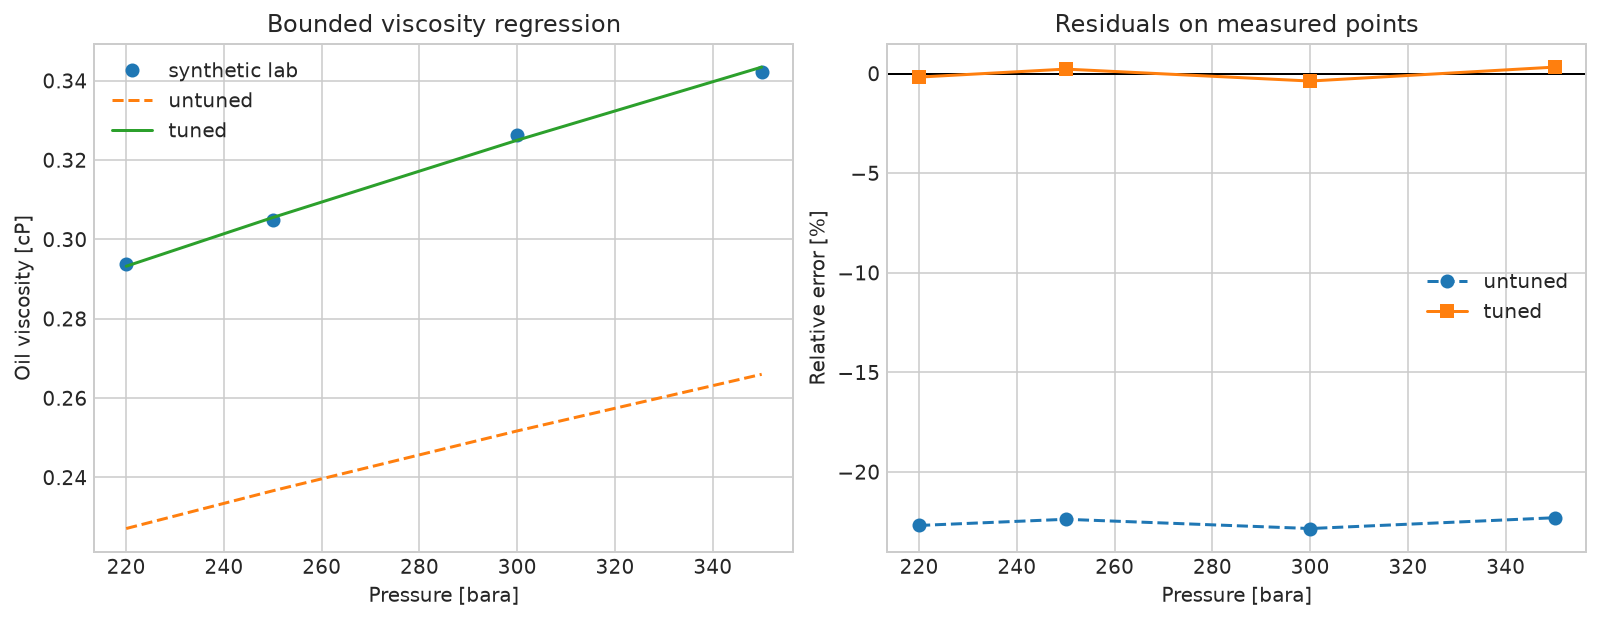

In [17]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

axes[0].plot(
    viscosity_pressures_bara,
    1000.0 * viscosity_lab_pa_s,
    "o",
    label="synthetic lab",
)
axes[0].plot(
    viscosity_pressures_bara,
    1000.0 * untuned_viscosity_pa_s,
    "--",
    label="untuned",
)
axes[0].plot(
    viscosity_pressures_bara,
    1000.0 * tuned_viscosity_pa_s,
    "-",
    label="tuned",
)
axes[0].set_xlabel("Pressure [bara]")
axes[0].set_ylabel("Oil viscosity [cP]")
axes[0].set_title("Bounded viscosity regression")
axes[0].legend()

axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].plot(
    viscosity_pressures_bara,
    untuned_error_percent,
    "o--",
    label="untuned",
)
axes[1].plot(
    viscosity_pressures_bara,
    tuned_error_percent,
    "s-",
    label="tuned",
)
axes[1].set_xlabel("Pressure [bara]")
axes[1].set_ylabel("Relative error [%]")
axes[1].set_title("Residuals on measured points")
axes[1].legend()

plt.show()

### Regression interpretation

The tuned parameter should recover the hidden reference to within the measurement perturbation,
while the independently calculated AARD should fall below 1%. The uncertainty object currently
provides a simplified screening approximation; it is not a substitute for a covariance analysis,
bootstrap, profile likelihood, or blind validation against held-out laboratory points.

## 9. Optimize first-stage separator conditions

The built-in optimizer searches a pressure-temperature grid and minimizes separator-test $B_o$.
This is equivalent to maximizing the stock-tank recovery proxy

$$
R_{\mathrm{STO}} = \frac{1}{B_o}.
$$

A separate explicit grid is calculated to make the objective surface auditable and to cross-check
the optimizer result.

In [18]:
optimization_pressures_bara = np.linspace(30.0, 90.0, 7)
optimization_temperatures_C = np.linspace(30.0, 60.0, 4)
optimization_rows = []

for hp_pressure_bara in optimization_pressures_bara:
    for hp_temperature_C in optimization_temperatures_C:
        trial = MultiStageSeparatorTest(tuned_fluid.clone())
        trial.setReservoirConditions(
            RESERVOIR_PRESSURE_BARA,
            RESERVOIR_TEMPERATURE_C,
        )
        trial.addSeparatorStage(
            float(hp_pressure_bara),
            float(hp_temperature_C),
            "HP separator",
        )
        trial.addSeparatorStage(15.0, 35.0, "LP separator")
        trial.addStockTankStage()
        trial.run()
        optimization_rows.append(
            {
                "HP_pressure_bara": hp_pressure_bara,
                "HP_temperature_C": hp_temperature_C,
                "Bo_rm3_Sm3": trial.getBo(),
                "recovery_Sm3_rm3": 1.0 / trial.getBo(),
                "GOR_Sm3_Sm3": trial.getTotalGOR(),
            }
        )

separator_optimization_grid = pd.DataFrame(optimization_rows)
best_grid_row = separator_optimization_grid.loc[
    separator_optimization_grid["Bo_rm3_Sm3"].idxmin()
]

optimizer_test = MultiStageSeparatorTest(tuned_fluid.clone())
optimizer_test.setReservoirConditions(
    RESERVOIR_PRESSURE_BARA,
    RESERVOIR_TEMPERATURE_C,
)
optimizer_test.addSeparatorStage(60.0, 45.0, "HP separator")
optimizer_test.addSeparatorStage(15.0, 35.0, "LP separator")
optimizer_test.addStockTankStage()
optimizer_result = optimizer_test.optimizeFirstStageSeparator(
    30.0,
    90.0,
    7,
    30.0,
    60.0,
    4,
)

optimization_summary = pd.DataFrame(
    {
        "quantity": [
            "explicit-grid pressure",
            "built-in optimizer pressure",
            "explicit-grid temperature",
            "built-in optimizer temperature",
            "maximum recovery",
            "GOR at optimum",
        ],
        "value": [
            best_grid_row["HP_pressure_bara"],
            optimizer_result.getOptimalPressure(),
            best_grid_row["HP_temperature_C"],
            optimizer_result.getOptimalTemperature(),
            optimizer_result.getMaximumOilRecovery(),
            optimizer_result.getGorAtOptimum(),
        ],
        "unit": ["bara", "bara", "°C", "°C", "Sm3/rm3", "Sm3/Sm3"],
    }
)
display(separator_optimization_grid)
display(optimization_summary)

,HP_pressure_bara,HP_temperature_C,Bo_rm3_Sm3,recovery_Sm3_rm3,GOR_Sm3_Sm3
0,30.0,30.0,1.426425,0.701053,137.177700
1,30.0,40.0,1.428991,0.699795,137.820763
2,30.0,50.0,1.432680,0.697993,138.727906
3,30.0,60.0,1.437687,0.695562,139.937909
4,40.0,30.0,1.426290,0.701120,137.127056
5,40.0,40.0,1.428109,0.700227,137.578107
6,40.0,50.0,1.430775,0.698922,138.228881
7,40.0,60.0,1.434457,0.697128,139.113579
8,50.0,30.0,1.426595,0.700970,137.201971
9,50.0,40.0,1.427995,0.700283,137.543280


,quantity,value,unit
0,explicit-grid pressure,40.000000,bara
1,built-in optimizer pressure,40.000000,bara
2,explicit-grid temperature,30.000000,°C
3,built-in optimizer temperature,30.000000,°C
4,maximum recovery,0.701120,Sm3/rm3
5,GOR at optimum,137.127056,Sm3/Sm3


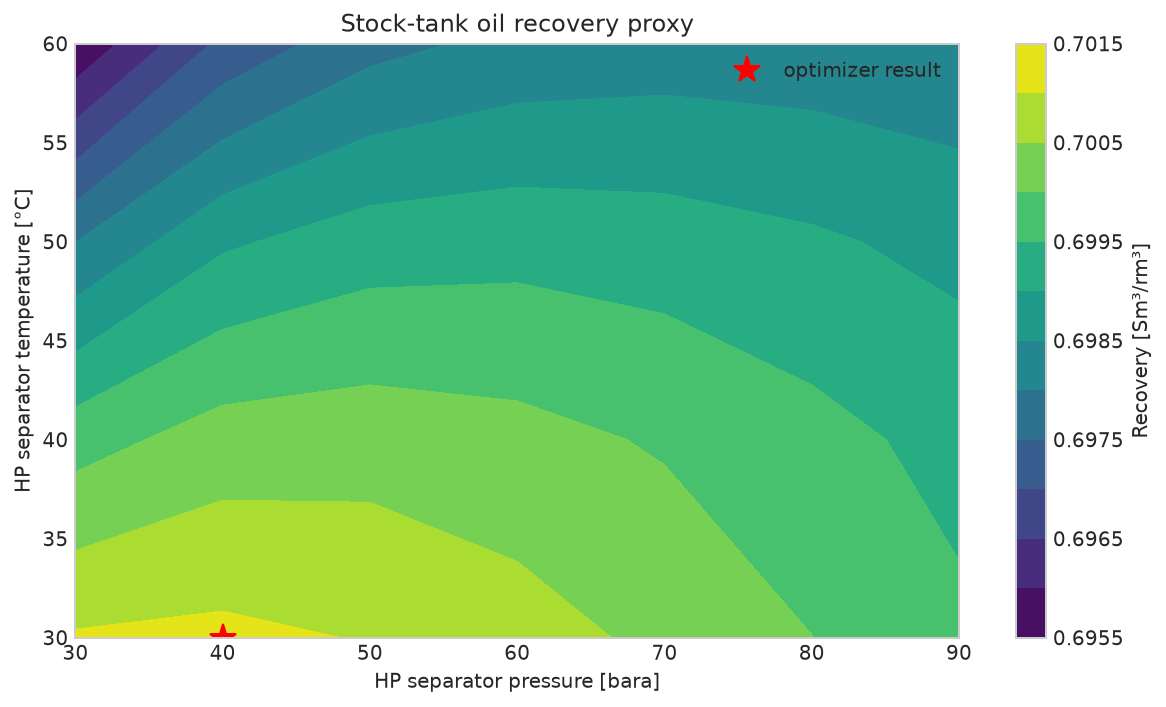

In [19]:
recovery_surface = separator_optimization_grid.pivot(
    index="HP_temperature_C",
    columns="HP_pressure_bara",
    values="recovery_Sm3_rm3",
)

figure, axis = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
contour = axis.contourf(
    recovery_surface.columns,
    recovery_surface.index,
    recovery_surface.to_numpy(),
    levels=12,
    cmap="viridis",
)
axis.plot(
    optimizer_result.getOptimalPressure(),
    optimizer_result.getOptimalTemperature(),
    "r*",
    markersize=14,
    label="optimizer result",
)
axis.set_xlabel("HP separator pressure [bara]")
axis.set_ylabel("HP separator temperature [°C]")
axis.set_title("Stock-tank oil recovery proxy")
axis.legend()
figure.colorbar(contour, ax=axis, label="Recovery [Sm³/rm³]")
plt.show()

## 10. Generate the auditable PVT report

`PVTReportGenerator` collects project metadata, composition, saturation pressure, CCE, DLE, and
lab comparison data. The built-in Markdown study report and the separate lab-comparison section
are combined below so that the saved notebook contains the complete human-readable result.

In [20]:
tuned_cce = ConstantMassExpansion(tuned_fluid.clone())
tuned_cce.setPressures(cce_pressures_bara.tolist())
tuned_cce.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
tuned_cce.runCalc()

tuned_dle = DifferentialLiberation(tuned_fluid.clone())
tuned_dle.setPressures(dle_pressures_bara.tolist())
tuned_dle.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
tuned_dle.runCalc()

PVTReportGenerator = jneqsim.pvtsimulation.util.PVTReportGenerator
pvt_report = PVTReportGenerator(tuned_fluid.clone())
pvt_report.setProjectInfo(
    "Synthetic oil PVT workflow",
    "Teaching-BHS-01",
)
pvt_report.setLabInfo("Synthetic teaching laboratory", "2026-07-22")
pvt_report.setReservoirConditions(
    RESERVOIR_PRESSURE_BARA,
    RESERVOIR_TEMPERATURE_C,
)
pvt_report.addSaturationPressure(saturation_calculation)
pvt_report.addCCE(tuned_cce)
pvt_report.addDLE(tuned_dle)

for pressure_bara, lab_relative_volume in zip(
    cce_pressures_bara,
    cce_lab_relative_volume,
):
    pvt_report.addLabCCEData(
        float(pressure_bara),
        "RelVol",
        float(lab_relative_volume),
        "-",
    )

for pressure_bara, lab_bo, lab_rs in zip(
    dle_pressures_bara,
    dle_bo_lab,
    dle_rs_lab,
):
    pvt_report.addLabDLEData(
        float(pressure_bara),
        "Bo",
        float(lab_bo),
        "m3/Sm3",
    )
    if lab_rs > 0.0:
        pvt_report.addLabDLEData(
            float(pressure_bara),
            "Rs",
            float(lab_rs),
            "Sm3/Sm3",
        )

pvt_report_markdown = str(pvt_report.generateMarkdownReport())
lab_comparison_markdown = str(pvt_report.generateLabComparison())
complete_report_markdown = (
    pvt_report_markdown
    + "\n\n"
    + lab_comparison_markdown
)
display(Markdown(complete_report_markdown))

# PVT Study Report

## Project Information

| Property | Value |
|----------|-------|
| Project | Synthetic oil PVT workflow |
| Fluid Name | Teaching-BHS-01 |
| Laboratory | Synthetic teaching laboratory |
| Sample Date | 2026-07-22 |
| Report Date | 2026-07-23 03:02 |

## Reservoir Conditions

| Property | Value | Unit |
|----------|-------|------|
| Reservoir Pressure | 300.0 | bara |
| Reservoir Temperature | 97.5 | °C |
| Bubble Point Pressure | 193.24 | bara |

## Fluid Composition

| Component | Mole Fraction | MW (g/mol) |
|-----------|--------------|------------|
| nitrogen | 0.003900 | 28.01 |
| CO2 | 0.003000 | 44.01 |
| methane | 0.402000 | 16.04 |
| ethane | 0.076100 | 30.07 |
| propane | 0.079500 | 44.10 |
| i-butane | 0.011900 | 58.12 |
| n-butane | 0.040800 | 58.12 |
| i-pentane | 0.013900 | 72.15 |
| n-pentane | 0.021500 | 72.15 |
| n-hexane | 0.027900 | 86.18 |
| PC1_PC | 0.085900 | 100.52 |
| PC2_PC | 0.055500 | 127.23 |
| PC3_PC | 0.036000 | 154.10 |
| PC4_PC | 0.028100 | 184.12 |
| PC5_PC | 0.032400 | 221.03 |
| PC6_PC | 0.019866 | 258.09 |
| PC7_PC | 0.018903 | 316.08 |
| PC8_PC | 0.015315 | 391.88 |
| PC9_PC | 0.011232 | 481.99 |
| PC10_PC | 0.008808 | 596.77 |
| PC11_PC | 0.006387 | 782.66 |
| PC12_PC | 0.001088 | 1022.05 |

## Constant Composition Expansion (CCE)

| Pressure (bara) | Rel. Volume | Y-Factor | Density (kg/m³) |
|-----------------|-------------|----------|-----------------|
| 300.0 | 0.9691 | - | 669.0 |
| 250.0 | 0.9822 | - | 659.6 |
| 220.0 | 0.9911 | - | 653.3 |
| 200.0 | 0.9977 | - | 648.8 |
| 193.2 | 1.0000 | - | 647.2 |
| 180.0 | 1.0280 | 2.6147 | 154.4 |
| 150.0 | 1.1181 | 2.4373 | 125.7 |
| 100.0 | 1.4354 | 2.1401 | 81.4 |

## Differential Liberation Expansion (DLE)

| Pressure (bara) | Bo (m³/Sm³) | Rs (Sm³/Sm³) | ρ_oil (kg/m³) | Bg |
|-----------------|-------------|--------------|---------------|----|
| 300.0 | 1.7643 | 224.7 | 669.0 | 0.000000 |
| 250.0 | 1.7895 | 224.7 | 659.6 | 0.000000 |
| 220.0 | 1.8068 | 224.7 | 653.3 | 0.000000 |
| 200.0 | 1.8194 | 224.7 | 648.8 | 0.000000 |
| 180.0 | 1.7793 | 209.0 | 654.8 | 0.006301 |
| 150.0 | 1.6875 | 176.5 | 672.2 | 0.007562 |
| 100.0 | 1.5527 | 129.0 | 701.6 | 0.011533 |
| 50.0 | 1.4275 | 86.3 | 733.1 | 0.023873 |
| 1.0 | 1.0509 | 0.0 | 810.4 | 1.271652 |

## Quality Metrics

### CCE Comparison with Lab Data

*(Lab data comparison not yet implemented)*

### DLE Comparison with Lab Data

*(Lab data comparison not yet implemented)*

---
*Report generated by NeqSim PVT Report Generator*


## Lab Data Comparison

### CCE Comparison

| Pressure (bara) | Property | Lab Value | Sim Value | Deviation (%) |
|-----------------|----------|-----------|-----------|---------------|
| 300.0 | RelVol | 0.9701 | 0.9691 | 0.10 |
| 250.0 | RelVol | 0.9812 | 0.9822 | 0.10 |
| 220.0 | RelVol | 0.9931 | 0.9911 | 0.20 |
| 200.0 | RelVol | 0.9977 | 0.9977 | 0.00 |
| 193.2 | RelVol | 1.0010 | 1.0000 | 0.10 |
| 180.0 | RelVol | 1.0260 | 1.0280 | 0.20 |
| 150.0 | RelVol | 1.1204 | 1.1181 | 0.20 |
| 100.0 | RelVol | 1.4340 | 1.4354 | 0.10 |

**AAD (Average Absolute Deviation):** 0.0013
**ARE (Average Relative Error):** 0.12%

### DLE Comparison

| Pressure (bara) | Property | Lab Value | Sim Value | Deviation (%) |
|-----------------|----------|-----------|-----------|---------------|
| 300.0 | Bo | 1.7625 | 1.7643 | 0.10 |
| 300.0 | Rs | 225.1221 | 224.6727 | 0.20 |
| 250.0 | Bo | 1.7913 | 1.7895 | 0.10 |
| 250.0 | Rs | 224.4480 | 224.6727 | 0.10 |
| 220.0 | Bo | 1.8032 | 1.8068 | 0.20 |
| 220.0 | Rs | 224.8974 | 224.6727 | 0.10 |
| 200.0 | Bo | 1.8212 | 1.8194 | 0.10 |
| 200.0 | Rs | 224.2234 | 224.6727 | 0.20 |
| 180.0 | Bo | 1.7775 | 1.7793 | 0.10 |
| 180.0 | Rs | 209.4363 | 209.0183 | 0.20 |
| 150.0 | Bo | 1.6909 | 1.6875 | 0.20 |
| 150.0 | Rs | 176.3496 | 176.5262 | 0.10 |
| 100.0 | Bo | 1.5496 | 1.5527 | 0.20 |
| 100.0 | Rs | 129.1002 | 128.9712 | 0.10 |
| 50.0 | Bo | 1.4290 | 1.4275 | 0.10 |
| 50.0 | Rs | 86.1050 | 86.2776 | 0.20 |
| 1.0 | Bo | 1.0509 | 1.0509 | 0.00 |

**AAD (Average Absolute Deviation):** 0.1331
**ARE (Average Relative Error):** 0.14%



## 11. Create CSV handoff tables

The CCE and DLE CSV outputs come from the report generator. The viscosity fit and separator grid
are added as transparent pandas exports. All files are previewed in the notebook and later hashed.

In [21]:
output_directory = Path("pvt_workflow_outputs")
output_directory.mkdir(exist_ok=True)

csv_payloads = {
    "cce_results.csv": str(pvt_report.generateCCECSV()),
    "dle_results.csv": str(pvt_report.generateDLECSV()),
    "viscosity_regression.csv": viscosity_fit_table.to_csv(index=False),
    "separator_optimization.csv": separator_optimization_grid.to_csv(index=False),
}

for file_name, csv_text in csv_payloads.items():
    (output_directory / file_name).write_text(csv_text, encoding="utf-8")

csv_preview = pd.DataFrame(
    {
        "file": csv_payloads.keys(),
        "line_count": [text.count("\n") for text in csv_payloads.values()],
        "first_line": [text.splitlines()[0] for text in csv_payloads.values()],
    }
)
display(csv_preview)
print(csv_payloads["cce_results.csv"])

Pressure(bara),RelativeVolume,YFactor,Density(kg/m3)
300.00,0.969128,NaN,669.03
250.00,0.982206,NaN,659.60
220.00,0.991149,NaN,653.30
200.00,0.997666,NaN,648.78
193.24,0.999981,NaN,647.19
180.00,1.028020,2.614704,154.39
150.00,1.118130,2.437292,125.70
100.00,1.435433,2.140113,81.41



,file,line_count,first_line
0,cce_results.csv,9,"Pressure(bara),RelativeVolume,YFactor,Density(..."
1,dle_results.csv,10,"Pressure(bara),Bo(m3/Sm3),Rs(Sm3/Sm3),OilDensi..."
2,viscosity_regression.csv,5,"pressure_bara,lab_viscosity_cP,untuned_viscosi..."
3,separator_optimization.csv,29,"HP_pressure_bara,HP_temperature_C,Bo_rm3_Sm3,r..."


## 12. Build and validate an Eclipse black-oil include

The safest black-oil path is explicit:

1. derive a `BlackOilPVTTable` from the validated DLE schedule;
2. supply positive oil and gas viscosities in Pa s;
3. supply stock-tank densities explicitly;
4. export through `EclipseEOSExporter`; and
5. reject `NaN`, infinity, missing keywords, or non-positive densities.

This avoids treating a direct fluid-to-black-oil conversion as a validated project deck.

In [22]:
saturation_gas_state = tuned_fluid.clone()
saturation_gas_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
saturation_gas_state.setPressure(bubble_pressure_bara * 0.99, "bara")
TPflash(saturation_gas_state)
saturation_gas_state.initPhysicalProperties()
saturation_gas_viscosity_pa_s = (
    saturation_gas_state.getPhase("gas").getViscosity("cP") / 1000.0
)

black_oil_rows = []
for pressure_bara, rs_value, bo_value, bg_value in zip(
    dle_pressures_bara,
    np.asarray(tuned_dle.getRs(), dtype=float),
    np.asarray(tuned_dle.getBo(), dtype=float),
    np.asarray(tuned_dle.getBg(), dtype=float),
):
    property_state = tuned_fluid.clone()
    property_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    property_state.setPressure(float(pressure_bara), "bara")
    TPflash(property_state)
    property_state.initPhysicalProperties()
    oil_viscosity_pa_s = (
        property_state.getPhase("oil").getViscosity("cP") / 1000.0
    )
    if property_state.hasPhaseType("gas"):
        gas_viscosity_pa_s = (
            property_state.getPhase("gas").getViscosity("cP") / 1000.0
        )
    else:
        gas_viscosity_pa_s = saturation_gas_viscosity_pa_s

    black_oil_rows.append(
        {
            "pressure_bara": float(pressure_bara),
            "Rs_Sm3_Sm3": float(rs_value),
            "Bo_m3_Sm3": float(bo_value),
            "oil_viscosity_Pa_s": float(oil_viscosity_pa_s),
            "Bg_m3_Sm3": float(max(bg_value, 1.0e-6)),
            "gas_viscosity_Pa_s": float(gas_viscosity_pa_s),
        }
    )

black_oil_source_table = pd.DataFrame(black_oil_rows)
display(black_oil_source_table)

,pressure_bara,Rs_Sm3_Sm3,Bo_m3_Sm3,oil_viscosity_Pa_s,Bg_m3_Sm3,gas_viscosity_Pa_s
0,300.00000,224.672710,1.764295,0.000325,0.000001,0.000021
1,250.00000,224.672710,1.789529,0.000306,0.000001,0.000021
2,220.00000,224.672710,1.806786,0.000293,0.000001,0.000021
3,200.00000,224.672710,1.819362,0.000285,0.000001,0.000021
4,180.00000,209.018255,1.779300,0.000299,0.006301,0.000020
5,150.00000,176.526158,1.687488,0.000346,0.007562,0.000018
6,100.00000,128.971246,1.552728,0.000453,0.011533,0.000016
7,50.00000,86.277567,1.427528,0.000640,0.023873,0.000014
8,1.01325,0.000000,1.050859,0.002040,1.271652,0.000012


In [23]:
ArrayList = JClass("java.util.ArrayList")
BlackOilPVTTable = JClass("neqsim.blackoil.BlackOilPVTTable")
black_oil_records = ArrayList()

for row in black_oil_source_table.sort_values("pressure_bara").to_dict("records"):
    black_oil_records.add(
        BlackOilPVTTable.Record(
            row["pressure_bara"],
            row["Rs_Sm3_Sm3"],
            row["Bo_m3_Sm3"],
            row["oil_viscosity_Pa_s"],
            row["Bg_m3_Sm3"],
            row["gas_viscosity_Pa_s"],
            0.0,
            1.0,
            1.0e-3,
        )
    )

black_oil_table = BlackOilPVTTable(
    black_oil_records,
    tuned_dle.getSaturationPressure(),
)

stock_tank_state = tuned_fluid.clone()
stock_tank_state.setTemperature(STANDARD_TEMPERATURE_C, "C")
stock_tank_state.setPressure(STANDARD_PRESSURE_BARA, "bara")
TPflash(stock_tank_state)
stock_tank_state.initPhysicalProperties()
stock_oil_density_kg_m3 = stock_tank_state.getPhase("oil").getDensity("kg/m3")
stock_gas_density_kg_m3 = stock_tank_state.getPhase("gas").getDensity("kg/m3")

EclipseEOSExporter = jneqsim.blackoil.io.EclipseEOSExporter
export_configuration = EclipseEOSExporter.ExportConfig()
export_configuration.setUnits(EclipseEOSExporter.Units.METRIC)
export_configuration.setReferenceTemperature(RESERVOIR_TEMPERATURE_K)
export_configuration.setIncludePVTO(True)
export_configuration.setIncludePVTG(True)
export_configuration.setIncludePVTW(True)
export_configuration.setIncludeDensity(True)
export_configuration.setComment("Validated synthetic DLE-derived table")

black_oil_include = str(
    EclipseEOSExporter.toString(
        black_oil_table,
        stock_oil_density_kg_m3,
        stock_gas_density_kg_m3,
        WATER_DENSITY_60F_KG_M3,
        export_configuration,
    )
)
black_oil_path = output_directory / "PVT_TUNED_METRIC.INC"
black_oil_path.write_text(black_oil_include, encoding="utf-8")

black_oil_keyword_checks = {
    keyword: keyword in black_oil_include
    for keyword in ["DENSITY", "PVTO", "PVTG", "PVTW"]
}
black_oil_has_invalid_tokens = any(
    token in black_oil_include
    for token in ["NaN", "Infinity", "-Infinity"]
)

display(
    pd.DataFrame(
        {
            "keyword": black_oil_keyword_checks.keys(),
            "present": black_oil_keyword_checks.values(),
        }
    )
)
print("\n".join(black_oil_include.splitlines()[:32]))
print(f"Invalid numeric tokens present: {black_oil_has_invalid_tokens}")

-- ============================================================
-- Eclipse PVT Data Generated by NeqSim
-- Generated: 2026-07-23 03:02:58
-- Units: METRIC
-- Bubble Point: 193.19 BARSA
-- Validated synthetic DLE-derived table
-- ============================================================

-- Stock tank densities at standard conditions
-- Oil density, Water density, Gas density (KG/M3)
DENSITY
  832.4699  999.0160  1.123756 /

-- Live Oil PVT Table
-- Rs (SM3/SM3), P (BARSA), Bo (RM3/SM3), Viscosity (CP)
PVTO
  32.2404  19.3188  1.191614  1.517127
       49.3702  1.422685  0.658432
       79.4216  1.501199  0.530432
       109.4730  1.578259  0.433162
       139.5244  1.659254  0.368666
       169.5758  1.747397  0.315485
       193.1876  1.805716  0.289671
       199.6272  1.818615  0.285048
       229.6786  1.801219  0.297215
       259.7300  1.784619  0.309329
       289.7814  1.769452  0.321042
  /
  85.1683  49.3702  1.422685  0.658432
       79.4216  1.501199  0.530432
       109

,keyword,present
0,DENSITY,True
1,PVTO,True
2,PVTG,True
3,PVTW,True


## 13. Export and round-trip an E300 compositional fluid

E300 retains the compositional EOS representation. The exported text is read back into NeqSim,
flashed at the reservoir state, and checked for component count, composition closure, and a finite
compressibility factor. The round trip is a software handoff check, not a full cross-simulator
regression.

In [24]:
EclipseFluidReadWrite = jneqsim.thermo.util.readwrite.EclipseFluidReadWrite
e300_text = str(
    EclipseFluidReadWrite.toE300String(
        tuned_fluid,
        RESERVOIR_TEMPERATURE_C,
    )
)
e300_path = output_directory / "TUNED_FLUID.e300"
e300_path.write_text(e300_text, encoding="utf-8")

imported_fluid = EclipseFluidReadWrite.read(str(e300_path))
imported_fluid.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
imported_fluid.setPressure(RESERVOIR_PRESSURE_BARA, "bara")
TPflash(imported_fluid)
imported_fluid.initPhysicalProperties()

original_composition = np.array(
    [
        tuned_fluid.getComponent(index).getz()
        for index in range(tuned_fluid.getNumberOfComponents())
    ],
    dtype=float,
)
imported_composition = np.array(
    [
        imported_fluid.getComponent(index).getz()
        for index in range(imported_fluid.getNumberOfComponents())
    ],
    dtype=float,
)
maximum_round_trip_composition_error = np.max(
    np.abs(imported_composition - original_composition)
)

e300_round_trip = pd.DataFrame(
    {
        "check": [
            "original component count",
            "imported component count",
            "imported composition sum",
            "maximum composition difference",
            "imported phase count",
            "imported Z-factor",
        ],
        "value": [
            tuned_fluid.getNumberOfComponents(),
            imported_fluid.getNumberOfComponents(),
            imported_composition.sum(),
            maximum_round_trip_composition_error,
            imported_fluid.getNumberOfPhases(),
            imported_fluid.getZ(),
        ],
    }
)
display(e300_round_trip)
print("\n".join(e300_text.splitlines()[:42]))

-- Eclipse 300 Compositional EOS File
-- Generated by NeqSim on 2026-07-23 03:02:58
-- EOS: SRK
--
METRIC
-- Number of components:
NCOMPS
22 /
-- Equation of state
EOS
SRK /
-- Reservoir temperature (C)
RTEMP
    97.50 /
-- Standard Conditions (C and bara)
STCOND
   15.00000    1.01325  /
-- Component names
CNAMES
N2
CO2
C1
C2
C3
iC4
C4
iC5
C5
C6
PC1
PC2
PC3
PC4
PC5
PC6
PC7
PC8
PC9
PC10
PC11
PC12
/


,check,value
0,original component count,2.200000e+01
1,imported component count,2.200000e+01
2,imported composition sum,1.000000e+00
3,maximum composition difference,9.778250e-11
4,imported phase count,1.000000e+00
5,imported Z-factor,1.356758e+00


## 14. Artifact manifest and deterministic hashes

Hashes help prove exactly which report and simulator handoff files were reviewed. They are not
signatures and do not establish technical approval.

In [25]:
report_path = output_directory / "PVT_WORKFLOW_REPORT.md"
report_path.write_text(complete_report_markdown, encoding="utf-8")

artifact_rows = []
for artifact_path in sorted(output_directory.iterdir()):
    artifact_bytes = artifact_path.read_bytes()
    artifact_rows.append(
        {
            "file": artifact_path.name,
            "bytes": len(artifact_bytes),
            "sha256": hashlib.sha256(artifact_bytes).hexdigest(),
        }
    )

artifact_manifest = pd.DataFrame(artifact_rows)
display(artifact_manifest)

,file,bytes,sha256
0,PVT_TUNED_METRIC.INC,3390,dff82bcbc64f410c7ce364e46d72bb28f3db8af13d78a4...
1,PVT_WORKFLOW_REPORT.md,4114,89ec26cbe05ba7e531791ad5d81338c73b660e2b235447...
2,TUNED_FLUID.e300,9201,f091ce510fea0245b54f550137b015ded1a941d137a3e6...
3,cce_results.csv,283,c94a02721223af3d41cf0e7c6499c39fa2b825c547d2a6...
4,dle_results.csv,422,672ab6f60aad4ca2bdbd46536395b0a78875ca6883f31f...
5,separator_optimization.csv,1933,f396efa621f5d92eaf7744ef30ac22c88d66246eed8b64...
6,viscosity_regression.csv,528,2f9d1bd2169ddd9917f14a81e8641b82ac83a6a1854101...


## 15. Executable engineering acceptance checks

The final gate verifies composition, phase behaviour, experiment trends, regression recovery,
separator optimization, report content, CSV schemas, and both simulator exports. Any failed check
stops the notebook.

In [26]:
above_bubble = dle_pressures_bara > bubble_pressure_bara
below_bubble = dle_pressures_bara < bubble_pressure_bara
positive_rs = dle_rs > 0.0

validation_checks = {
    "input assay closes to 100 mol%": abs(assay_total_mol_percent - 100.0)
    < 1.0e-10,
    "characterized composition closes": abs(characterized_sum - 1.0) < 1.0e-12,
    "characterization produced 22 components": reservoir_oil.getNumberOfComponents()
    == 22,
    "reference state is single-phase oil": reference_state.getNumberOfPhases() == 1,
    "reference density is plausible": 600.0 < reference_density_kg_m3 < 800.0,
    "bubble pressure is in the expected range": 150.0 < bubble_pressure_bara < 250.0,
    "CCE is normalized near the bubble point": abs(
        cce_calculated_relative_volume[4] - 1.0
    )
    < 1.0e-3,
    "CCE comparison AARD is below 0.5%": cce_aard_percent < 0.5,
    "DLE Rs is constant above bubble": np.ptp(dle_rs[above_bubble]) < 1.0e-8,
    "DLE Rs decreases below bubble": np.all(np.diff(dle_rs[below_bubble]) < 0.0),
    "DLE Bo decreases below bubble": np.all(np.diff(dle_bo[below_bubble]) < 0.0),
    "positive DLE results are finite": np.isfinite(
        np.concatenate(
            [dle_bo, dle_rs[positive_rs], dle_density_kg_m3, dle_bg]
        )
    ).all(),
    "separator pressures decrease by stage": separator_stage_results[
        "pressure_bara"
    ].is_monotonic_decreasing,
    "separator GOR is positive": separator_test.getTotalGOR() > 0.0,
    "optimizer pressure matches explicit grid": abs(
        optimizer_result.getOptimalPressure()
        - best_grid_row["HP_pressure_bara"]
    )
    < 1.0e-12,
    "optimizer temperature matches explicit grid": abs(
        optimizer_result.getOptimalTemperature()
        - best_grid_row["HP_temperature_C"]
    )
    < 1.0e-12,
    "regression recovered the hidden factor": abs(
        optimized_viscosity_factor - SYNTHETIC_REFERENCE_FACTOR
    )
    < 0.01,
    "tuned viscosity AARD is below 1%": tuned_viscosity_aard_percent < 1.0,
    "regression improved viscosity AARD": tuned_viscosity_aard_percent
    < untuned_viscosity_aard_percent,
    "viscosity objective is finite": np.isfinite(viscosity_objective),
    "report contains CCE and DLE sections": all(
        heading in complete_report_markdown
        for heading in ["Constant Composition Expansion", "Differential Liberation"]
    ),
    "all CSV exports have headers and data": all(
        csv_text.count("\n") >= 2 for csv_text in csv_payloads.values()
    ),
    "black-oil export contains required keywords": all(
        black_oil_keyword_checks.values()
    ),
    "black-oil export has no invalid tokens": not black_oil_has_invalid_tokens,
    "black-oil stock densities are positive": min(
        stock_oil_density_kg_m3,
        stock_gas_density_kg_m3,
        WATER_DENSITY_60F_KG_M3,
    )
    > 0.0,
    "E300 component count survives round trip": imported_fluid.getNumberOfComponents()
    == tuned_fluid.getNumberOfComponents(),
    "E300 composition survives round trip": maximum_round_trip_composition_error
    < 1.0e-10,
    "E300 imported Z-factor is finite and positive": np.isfinite(
        imported_fluid.getZ()
    )
    and imported_fluid.getZ() > 0.0,
    "artifact manifest contains seven files": len(artifact_manifest) == 7,
}

validation_table = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "passed": validation_checks.values(),
    }
)
display(validation_table)

failed_checks = validation_table.loc[~validation_table["passed"], "check"].tolist()
if failed_checks:
    raise AssertionError(f"Failed validation checks: {failed_checks}")

print(f"All {len(validation_checks)} PVT workflow checks passed.")

All 29 PVT workflow checks passed.


,check,passed
0,input assay closes to 100 mol%,True
1,characterized composition closes,True
2,characterization produced 22 components,True
3,reference state is single-phase oil,True
4,reference density is plausible,True
5,bubble pressure is in the expected range,True
6,CCE is normalized near the bubble point,True
7,CCE comparison AARD is below 0.5%,True
8,DLE Rs is constant above bubble,True
9,DLE Rs decreases below bubble,True


## 16. Final result package

The table and JSON object below provide compact results for a downstream notebook, automated
workflow, or review record. The full tables and figures above remain the engineering evidence.

In [27]:
final_results = {
    "sample_id": "Teaching-BHS-01",
    "neqsim_version": VERSION_INFO["neqsim"],
    "eos": "SRK",
    "mixing_rule": "classic",
    "characterized_components": int(reservoir_oil.getNumberOfComponents()),
    "bubble_pressure_bara": float(bubble_pressure_bara),
    "cce_aard_percent": float(cce_aard_percent),
    "optimized_viscosity_factor": float(optimized_viscosity_factor),
    "tuned_viscosity_aard_percent": float(tuned_viscosity_aard_percent),
    "separator_total_gor_Sm3_Sm3": float(separator_test.getTotalGOR()),
    "separator_bo_rm3_Sm3": float(separator_test.getBo()),
    "optimal_hp_pressure_bara": float(optimizer_result.getOptimalPressure()),
    "optimal_hp_temperature_C": float(optimizer_result.getOptimalTemperature()),
    "black_oil_export_valid": bool(
        all(black_oil_keyword_checks.values())
        and not black_oil_has_invalid_tokens
    ),
    "e300_round_trip_max_composition_error": float(
        maximum_round_trip_composition_error
    ),
    "validation_checks_passed": int(validation_table["passed"].sum()),
    "validation_checks_total": int(len(validation_table)),
    "display_equations_verified": 6,
    "inline_equations_verified": 7,
    "mathjax_rendering": "passed",
    "stored_figures_visually_inspected": 3,
}

final_summary = pd.DataFrame(
    {
        "quantity": [
            "bubble pressure",
            "CCE AARD",
            "optimized viscosity factor",
            "tuned viscosity AARD",
            "separator total GOR",
            "separator Bo",
            "optimal HP pressure",
            "optimal HP temperature",
        ],
        "value": [
            final_results["bubble_pressure_bara"],
            final_results["cce_aard_percent"],
            final_results["optimized_viscosity_factor"],
            final_results["tuned_viscosity_aard_percent"],
            final_results["separator_total_gor_Sm3_Sm3"],
            final_results["separator_bo_rm3_Sm3"],
            final_results["optimal_hp_pressure_bara"],
            final_results["optimal_hp_temperature_C"],
        ],
        "unit": [
            "bara",
            "%",
            "-",
            "%",
            "Sm3/Sm3",
            "rm3/Sm3",
            "bara",
            "°C",
        ],
    }
)
display(final_summary)
print(json.dumps(final_results, indent=2, sort_keys=True))

{
  "black_oil_export_valid": true,
  "bubble_pressure_bara": 193.24093437194824,
  "cce_aard_percent": 0.12495034980124797,
  "characterized_components": 22,
  "display_equations_verified": 6,
  "e300_round_trip_max_composition_error": 9.778250431580204e-11,
  "eos": "SRK",
  "inline_equations_verified": 7,
  "mathjax_rendering": "passed",
  "mixing_rule": "classic",
  "neqsim_version": "3.16.0",
  "optimal_hp_pressure_bara": 40.0,
  "optimal_hp_temperature_C": 30.0,
  "optimized_viscosity_factor": 1.30027454901889,
  "sample_id": "Teaching-BHS-01",
  "separator_bo_rm3_Sm3": 1.4290119507267351,
  "separator_total_gor_Sm3_Sm3": 137.7895206671958,
  "stored_figures_visually_inspected": 3,
  "tuned_viscosity_aard_percent": 0.27489188096199546,
  "validation_checks_passed": 29,
  "validation_checks_total": 29
}


,quantity,value,unit
0,bubble pressure,193.240934,bara
1,CCE AARD,0.124950,%
2,optimized viscosity factor,1.300275,-
3,tuned viscosity AARD,0.274892,%
4,separator total GOR,137.789521,Sm3/Sm3
5,separator Bo,1.429012,rm3/Sm3
6,optimal HP pressure,40.000000,bara
7,optimal HP temperature,30.000000,°C


## Notebook validation evidence

- 27 of 27 code cells were executed top to bottom with stored outputs and no errors or stderr.
- All 29 engineering and handoff assertions passed.
- Six display equations and seven inline equations passed source checks, were rendered through a
  MathJax 3 SVG path, and were visually inspected for fractions, sums, subscripts, superscripts,
  Greek symbols, and units.
- Three stored PNG figures were visually inspected at original resolution.
- Notebook schema, unique cell IDs, Python syntax, teaching readability, output completeness,
  Colab badge target, catalog path, export previews, and deterministic hashes were checked.

Validation used NeqSim 3.16.0, Python 3.12.13, and OpenJDK 17.0.19 in a clean sequential
in-process execution. This evidence applies to the saved notebook revision.

## Applicability and remaining limitations

- The laboratory values are synthetic and correlated with the generating model; they demonstrate
  workflow mechanics, not predictive accuracy for a field fluid.
- Only one identifiable transport parameter is fitted. A project regression should use measured
  saturation, density, CCE, DLE/CVD, separator, and viscosity data with blind validation points.
- The framework uncertainty is an approximate screening result. Use a statistically defensible
  covariance or resampling method for parameter uncertainty and prediction intervals.
- The separator model assumes equilibrium stages and omits residence time, carry-over, emulsions,
  heat loss, control response, and mechanical constraints.
- The black-oil table is a reduced isothermal representation derived from the compositional DLE.
  Verify simulator-specific keyword conventions, monotonicity rules, interpolation, regions, and
  unit definitions before use.
- E300 round-trip validation proves NeqSim serialization consistency only. Run the receiving
  simulator and compare phase behaviour over the full pressure-temperature envelope.
- Gas-condensate CVD, CO₂ swelling, MMP, slim-tube, wax, and compositional-gradient studies require
  their own samples and acceptance criteria.

## Suggested extensions

1. Replace the synthetic tables with a licensed laboratory workbook and retain row-level provenance.
2. Add held-out saturation-pressure and density measurements before activating EOS parameters.
3. Run a parameter-sensitivity matrix and reject low-sensitivity or highly correlated parameters.
4. Compare SRK, PR, and a tuned model without changing the experimental basis.
5. Add gas-condensate CVD and CO₂ swelling using
   [Reservoir-fluid PVT experiments](PVTexperiments.ipynb).
6. Add deterministic report packaging using
   [Auditable PVT laboratory reports](PVTreports.ipynb).
7. Import the tuned E300 fluid into the receiving simulator and automate a cross-tool flash grid.

## References

- [NeqSim PVT workflow guide](https://equinor.github.io/neqsim/pvtsimulation/pvt_workflow.html)
- [NeqSim PVT simulation overview](https://equinor.github.io/neqsim/pvtsimulation/README.html)
- [PVTRegression source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/pvtsimulation/regression/PVTRegression.java)
- [PVTReportGenerator source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/pvtsimulation/util/PVTReportGenerator.java)
- [EclipseEOSExporter source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/blackoil/io/EclipseEOSExporter.java)
- [MultiStageSeparatorTest source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/pvtsimulation/simulation/MultiStageSeparatorTest.java)

This notebook is an educational engineering workflow. It is not a certified laboratory match,
reserves model, development basis, or simulator deck approval.